# Implementing an I2S Master on the iCE40UP5K FPGA
**Application:** Sending 24-bit I/Q SDR Data to an RP2040 (Raspberry Pi Pico)

In this project, our FPGA will act as the **I2S Master**, feeding audio/SDR data to an RP2040 acting as the **I2S Slave**. Because the RP2040 software is already configured to work with a PCM1808 ADC in master mode, our FPGA must mimic the timing and behavior of the PCM1808 perfectly. 

This means we must implement **Standard Philips I2S format**.

## 1. The Cast of Characters (The Signals)
To act as the I2S master, your FPGA will need to drive three output pins to the RP2040:
*   **BCK (Bit Clock):** The continuous high-speed clock that drives the serial data transfer.
*   **WS (Word Select) / LRCK:** This clock determines which audio channel (Left/I or Right/Q) is currently being transmitted. `WS = 0` means Left, `WS = 1` means Right.
*   **DATA / DOUT:** The serial audio data generated by the FPGA.

## 2. The Clock Math (The "Magic" Numbers)
Before writing any Hardware Description Language (HDL), we must calculate our timing parameters based on our system clock. 

*   **FPGA System Clock:** $30.720 \text{ MHz}$
*   **Sample Rate ($f_S$):** $48 \text{ kHz}$
*   **Frame Size:** 64 bits per WS frame (32 bits Left/I + 32 bits Right/Q)

Let's calculate our Bit Clock ($BCK$) frequency. We need 64 bits every sample period:
$$ BCK_{freq} = 48 \text{ kHz} \times 64 \text{ bits} = 3.072 \text{ MHz} $$

Now, how many FPGA System Clock cycles fit into one $BCK$ period?
$$ \frac{30.720 \text{ MHz}}{3.072 \text{ MHz}} = 10 \text{ cycles} $$

**This is a perfect integer ratio!** 
To generate a $3.072 \text{ MHz}$ square wave for $BCK$, the FPGA simply needs a counter that holds $BCK$ **LOW for 5 system clock cycles**, and **HIGH for 5 system clock cycles**.

---

## 3. The Golden Rule of I2S: Look at the Edges!
The most critical part of digital design is understanding **when signals change** and **when they are sampled**.

*   **The Falling Edge:** The FPGA must change `WS` and place new data bits on `DATA` exactly when `BCK` goes from **HIGH to LOW**.
*   **The Rising Edge:** During the rising edge of `BCK`, the `DATA` and `WS` lines are perfectly stable. The RP2040 (receiver) will sample the data on the **LOW to HIGH** transition.

**Rule for your FPGA logic:** *Your shift registers for `DATA` and `WS` must update on the falling edge of `BCK`.*

The timing diagram is here:

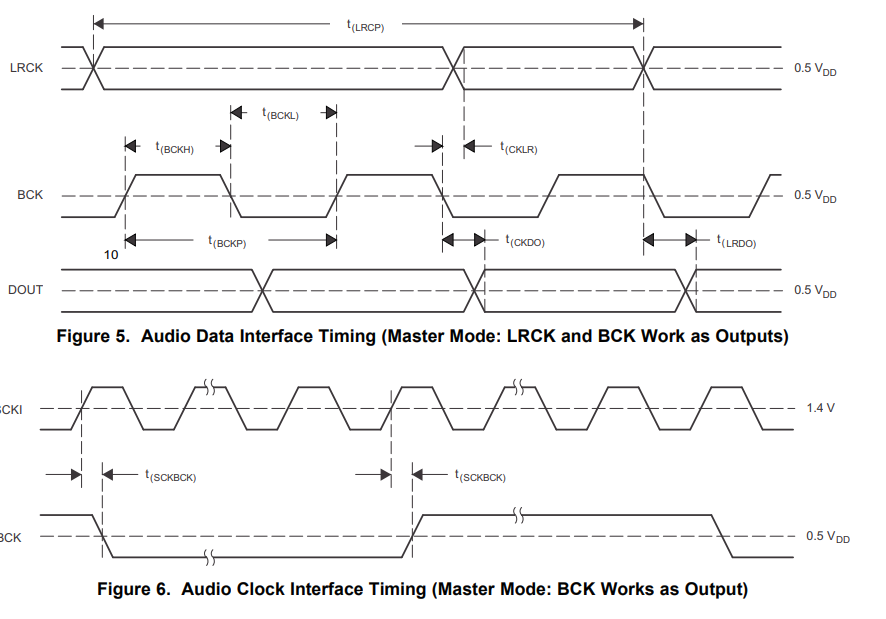

The times are given below.

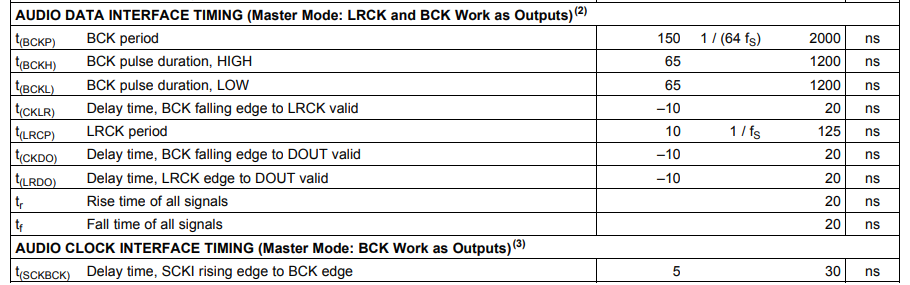

---

## 4. The Standard I2S "Gotcha": The 1-Bit Delay
We are mimicking the PCM1808 ADC, which outputs **Standard Philips I2S**. This standard has a famous quirk: **a 1-bit clock delay**.

When `WS` transitions (for example, from the Right channel to the Left channel), the very first data bit for the Left channel (the Most Significant Bit, MSB) is **NOT** sent out immediately. 

Here is the exact sequence of events for a channel swap:
1. `BCK` falls: `WS` changes from 1 to 0 (Right to Left). The `DATA` line *keeps holding the LSB of the previous Right channel*.
2. `BCK` rises: The RP2040 reads that delayed Right LSB.
3. `BCK` falls: The FPGA outputs the **Left Channel MSB**.
4. `BCK` rises: The RP2040 reads the Left Channel MSB.

*Note: If you do not include this 1-bit delay, you will accidentally implement a format called "Left-Justified", which will shift all your data by one bit in the RP2040 and completely corrupt the sign bit of your SDR I/Q data!*

---

## 5. FPGA Implementation Strategy
In modern FPGA design, it is bad practice to use a logic-generated signal (like `BCK`) as a true clock for other flip-flops. Instead, **run all logic on the $30.720 \text{ MHz}$ System Clock** and use a Master Counter.

### The Single-Counter Architecture
Since there are exactly 640 system clock cycles in one audio frame ($10 \text{ cycles/bit} \times 64 \text{ bits}$), create a single master counter:
`logic [9:0] sys_cnt; // Counts from 0 to 639`

Here is a blueprint for your logic based on the value of `sys_cnt`:

*   **0 to 319:** Left Channel / I Data (`WS` = 0)
*   **320 to 639:** Right Channel / Q Data (`WS` = 1)

**Inside every 10-cycle bit period (e.g., cycles 0-9, 10-19, etc.):**
*   `sys_cnt % 10 == 0`: `BCK` goes **LOW**. (This is the simulated falling edge where you shift data).
*   `sys_cnt % 10 == 5`: `BCK` goes **HIGH**. (This is the simulated rising edge where the RP2040 reads).

**Handling the 1-Bit Delay:**
*   `sys_cnt == 0`: `WS` drops to 0. *Do not output Left MSB yet!* Output the dummy bit/Right LSB.
*   `sys_cnt == 10`: Output **Left MSB** (Bit 23 of your 24-bit data).
*   `sys_cnt == 20`: Output **Left Bit 22**, and so on.
*   ...
*   `sys_cnt == 320`: `WS` goes to 1. *Do not output Right MSB yet!* Output the dummy bit/Left LSB.
*   `sys_cnt == 330`: Output **Right MSB** (Bit 23 of your 24-bit data).

*(Because we are sending 24-bit data in a 32-bit slot, ensure your state machine pads the final 8 bits of each channel with logic `0`s).*

---

## 6. Checklist for FPGA Sign-Off
Before moving to the physical iCE40UP5K hardware, ensure your SystemVerilog simulations pass this checklist:

- [ ] Does `BCK` run at exactly $3.072 \text{ MHz}$?
- [ ] Does `WS` run at $48 \text{ kHz}$?
- [ ] Do `WS` and `DATA` update **only** when `BCK` transitions from HIGH to LOW?
- [ ] **The I2S Test:** When `WS` transitions, does the `DATA` line wait for one extra `BCK` cycle before shifting out the Most Significant Bit (MSB)?
- [ ] Are the last 8 bits of both channels correctly padded with `0`s?